In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate some example data
np.random.seed(10)
data = 2.4*np.random.rand(128)

# Create the histogram
plt.figure(figsize=(8, 6))  # Set the figure size

# Plot the histogram
plt.hist(data, bins=30, color='tab:purple', edgecolor='black', alpha=0.7)

# Customize the plot
plt.title('Distribution of Activation Mean', fontsize=16)
plt.xlabel('Mean value of Activation', fontsize=14)
plt.ylabel('Frequency of Activation', fontsize=14)

# Add grid lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a legend (optional)
# plt.legend(['Data'])

# Customize tick marks and labels
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add a horizontal line at y=0 (optional)
plt.axhline(0, color='black',linewidth=0.5)

# Save the figure (optional)
# plt.savefig('histogram.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()



In [56]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.io import read_image
from torchvision import transforms
# Load a pre-trained ResNet model

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

resnet_model = models.resnet152(pretrained=True)
resnet_model = resnet_model.to(DEVICE)
resnet_model.eval()
img_drone_clean = read_image('drone-clean.png')[:3].float()#.convert("RGB")
img_drone_fog = read_image('drone-fog.png')[:3].float()#.convert("RGB")

img_drone_clean = img_drone_clean/255.0
img_drone_fog = img_drone_fog/255.0

#normlayer_names = []
# Print the named modules
#for name, module in resnet_model.named_modules():
#    if isinstance(module, nn.BatchNorm2d):
#        normlayer_names.append(name)
transform = transforms.Compose(
    [#transforms.ToTensor(),
     transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]),
     transforms.CenterCrop(size=(256,256))
])
img_drone_clean = transform(img_drone_clean)
img_drone_fog = transform(img_drone_fog)

In [85]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.io import read_image
from torchvision import transforms
# Load a pre-trained ResNet model

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

#resnet_model = torch.hub.load('pytorch/vision:v0.10.0', 'mobilenet_v2', pretrained=True)
resnet_model = models.resnet152(pretrained=True)
resnet_model = resnet_model.to(DEVICE)
resnet_model.eval()
img_drone_clean = read_image('File.jpg')[:3].float()#.convert("RGB")
img_drone_fog = read_image('drone-fog.png')[:3].float()#.convert("RGB")

img_drone_clean = img_drone_clean/255.0
#img_drone_fog = img_drone_fog/255.0

#normlayer_names = []
# Print the named modules
#for name, module in resnet_model.named_modules():
#    if isinstance(module, nn.BatchNorm2d):
#        normlayer_names.append(name)
transform = transforms.Compose(
    [#transforms.ToTensor(),
     transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]),
     transforms.Resize(size=(256,256))
])
img_drone_clean = transform(img_drone_clean)
img_drone_fog = transform(img_drone_fog)

/home/client1/anaconda3/envs/pytorch/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/client1/anaconda3/envs/pytorch/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet152_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet152_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/client1/anaconda3/envs/pytorch/lib/python3.11/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Te

In [86]:
print(img_drone_clean[:3].shape)
print(img_drone_fog[:3].shape)
img_drone_clean = img_drone_clean.to(DEVICE)
img_drone_fog = img_drone_fog.to(DEVICE)

torch.Size([3, 256, 256])
torch.Size([3, 256, 256])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


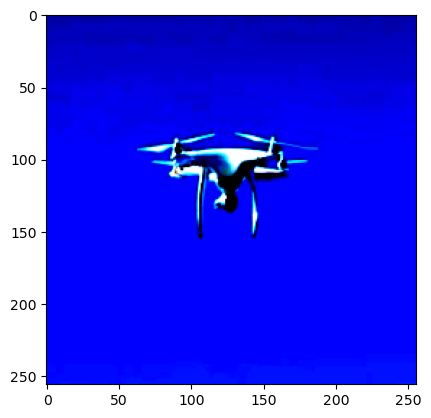

In [73]:
import matplotlib.pyplot as plt
img_drone_clean = img_drone_clean.numpy().transpose(1, 2, 0)
plt.imshow(img_drone_clean)
plt.show()

In [87]:
in_labels= "imagenet1000_clsidx_to_labels.txt"
imagenetLabels = dict(enumerate(open(in_labels)))
logits = resnet_model(img_drone_clean.unsqueeze(0))
probabilities = nn.Softmax(dim=-1)(logits)
sortedProba = torch.argsort(probabilities, dim=-1, descending=True)
for (i, idx) in enumerate(sortedProba[0, :5]):
	print("{}. {}: {:.2f}%".format
		(i, imagenetLabels[idx.item()].strip(),
		probabilities[0, idx.item()] * 100))


0. 895: 'warplane, military plane',: 52.54%
1. 146: 'albatross, mollymawk',: 8.47%
2. 404: 'airliner',: 4.61%
3. 744: 'projectile, missile',: 3.23%
4. 4: 'hammerhead, hammerhead shark',: 2.49%


In [78]:
in_labels= "imagenet1000_clsidx_to_labels.txt"
imagenetLabels = dict(enumerate(open(in_labels)))
logits = resnet_model(img_drone_fog.unsqueeze(0))
probabilities = nn.Softmax(dim=-1)(logits)
sortedProba = torch.argsort(probabilities, dim=-1, descending=True)
for (i, idx) in enumerate(sortedProba[0, :5]):
	print("{}. {}: {:.2f}%".format
		(i, imagenetLabels[idx.item()].strip(),
		probabilities[0, idx.item()] * 100))


0. 561: 'forklift',: 99.88%
1. 783: 'screw',: 0.06%
2. 644: 'matchstick',: 0.04%
3. 754: 'radio, wireless',: 0.01%
4. 966: 'red wine',: 0.00%


In [11]:
def get_named_submodule(model, sub_name: str):
    names = sub_name.split(".")
    module = model
    for name in names:
        module = getattr(module, name)

    return module

In [29]:
get_named_submodule(resnet_model, normlayer_names[1])

BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [31]:
names = normlayer_names[1].split(".")
module = resnet_model
for name in names:
    module = getattr(module, name)
print(module)

BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


In [3]:
from torchvision import transforms, datasets
transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean = (0.485, 0.456, 0.406),
                std = (0.229, 0.224, 0.225))
        ]) 
dataset = datasets.CIFAR10(root ='data/', train=True, download=True, transform=transform)
len(dataset)

Files already downloaded and verified


50000